# 文章データ分析
## データセットの読み込み
各行が1通のメールに対応している
- type: メールの分類
  - 1: スパム (spam)
  - 0: スパムではない (ham)
- text: 本文

In [27]:
import pandas as pd

# email.csv を読み込んで，データフレーム形式で email に代入
email = pd.read_csv("email.csv")

# 内容の確認（emailの表示）
display(email)

,type,text
0,0,Go until jurong point crazy.. Available only ...
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,Nah I don't think he goes to usf he lives aro...
...,...,...
5566,0,Why don't you wait 'til at least wednesday to ...
5567,0,Huh y lei...
5568,1,REMINDER FROM O2: To get 2.50 pounds free call...
5569,1,This is the 2nd time we have tried 2 contact u...


## スパムメールの分析
- ワードクラウドを作成して，頻出単語を可視化する

In [28]:
# スパムメール (type が 1) の行だけを選んで spam に代入
spam = email[email["type"]==1]

# スパムではないメール (type が 0) の行だけを選んで ham に代入
ham = email[email["type"]==0]

# 内容の確認（spam と ham を順に表示）
display(spam)
display(ham)

,type,text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,SIX chances to win CASH! From 100 to 20 000 po...
...,...,...
5539,1,Want explicit SEX in 30 secs? Ring 02073162414...
5542,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5549,1,Had your contract mobile 11 Mnths? Latest Moto...
5568,1,REMINDER FROM O2: To get 2.50 pounds free call...


,type,text
0,0,Go until jurong point crazy.. Available only ...
1,0,Ok lar... Joking wif u oni...
3,0,U dun say so early hor... U c already then say...
4,0,Nah I don't think he goes to usf he lives aro...
6,0,Even my brother is not like to speak with me. ...
...,...,...
5564,0,Ok lor... Sony ericsson salesman... I ask shuh...
5565,0,Ard 6 like dat lor.
5566,0,Why don't you wait 'til at least wednesday to ...
5567,0,Huh y lei...


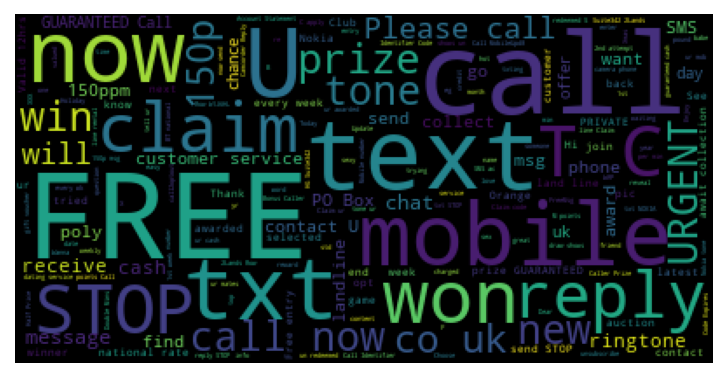

In [29]:
# 全てのスパムメールの本文を (空白文字をはさんで) 連結して spam_words に代入
spam_words = " ".join(spam["text"])

# WordCloud オブジェクトを spam_wc に代入
from wordcloud import WordCloud
spam_wc = WordCloud()

# spam_words を元にして，spam_wc 内の WordCloud オブジェクトにワードクラウドを生成する
spam_wc.generate(spam_words)

# 生成したイメージを，pyplot を使って表示する
import matplotlib.pyplot as plt
plt.figure(dpi=150)     # 大きなイメージで表示する
plt.imshow(spam_wc)
plt.axis("off")         # 軸目盛りの非表示
plt.show()

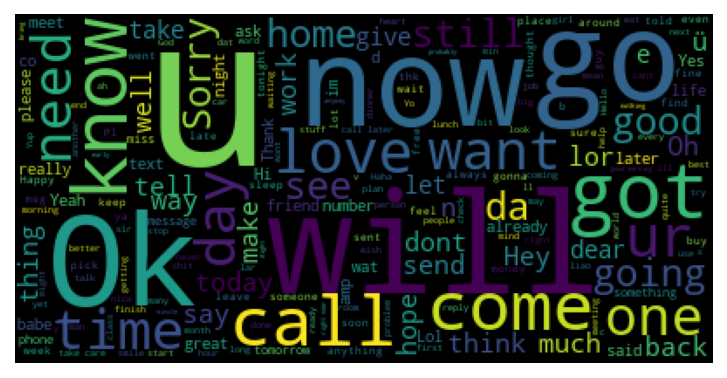

In [30]:
# スパムではないメールでも，同様の操作を行う
ham_words = " ".join(ham["text"])
ham_wc = WordCloud()
ham_wc.generate(ham_words)
plt.figure(dpi=150)
plt.imshow(ham_wc)
plt.axis("off")
plt.show()

## スパムメールフィルターの作成
### 前処理

In [31]:
# メール本文の大文字を全て小文字に変換
email["text"] = email["text"].str.lower()

# 内容の確認（emailの表示）
display(email)

,type,text
0,0,go until jurong point crazy.. available only ...
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,nah i don't think he goes to usf he lives aro...
...,...,...
5566,0,why don't you wait 'til at least wednesday to ...
5567,0,huh y lei...
5568,1,reminder from o2: to get 2.50 pounds free call...
5569,1,this is the 2nd time we have tried 2 contact u...


In [32]:
# ストップワードの除去
stop_words = ["the", "a", "an", "in", "on", "at", "by", "for", "of", "to", "is", "are", "am"]
for w in stop_words:
    email["text"] = email["text"].str.replace(f" {w} ", " ")

# 内容の確認（emailの表示）
display(email)

,type,text
0,0,go until jurong point crazy.. available only ...
1,0,ok lar... joking wif u oni...
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say so early hor... u c already then say...
4,0,nah i don't think he goes usf he lives around...
...,...,...
5566,0,why don't you wait 'til least wednesday see if...
5567,0,huh y lei...
5568,1,reminder from o2: get 2.50 pounds free call cr...
5569,1,this 2nd time we have tried 2 contact u. u hav...


### 形態素解析
(というか，単語とその出現頻度をカウントしているだけ)

- CountVectorizer オブジェクトを使用する
  - 単語のリストを作成する
  - 各入力文に対して，どの単語が何回出現したかの情報をテーブルの形で生成する
    - 行が入力データ (メール) に対応
    - 列は各単語に対応
    - 各フィールドの値は，その行の入力データに，その列の語が出現した回数
  - あらかじめ，単語の最少出現回数 (min_df) を決めておくことができる

In [33]:
# CountVectorizer オブジェクトを生成して vector に代入
from sklearn.feature_extraction.text import CountVectorizer
vector = CountVectorizer(min_df=3)

# email["text"] で3回以上出現した単語のリストを作成する
vector.fit(email["text"])

# (3回以上出現した)単語数の表示
print("単語数：", len(vector.vocabulary_))

単語数： 2817


In [34]:
# email["text"] の各文ごとの，単語出現回数の表を text_vec に代入
text_vec = vector.transform(email["text"])

# 内容の確認（text_vec の表示，さらに "free" の列だけ抜粋して表示
text_vec_df = pd.DataFrame(text_vec.toarray(), columns=vector.get_feature_names_out())
display(text_vec_df)
display(text_vec_df["free"])

,00,000,02,0207,03,04,05,06,07xxxxxxxxx,0800,...,yr,yrs,yummy,yun,yup,zed,áeall,áegot,áestill,áewan
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5566,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5569,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


0       0
1       0
2       1
3       0
4       0
       ..
5566    0
5567    0
5568    1
5569    0
5570    0
Name: free, Length: 5571, dtype: int64

### スパム分類AIの作成
- ナイーブベイズというモデルを使用する (<u>「素朴な」ベイズ推定</u>という方法を用いる)

In [35]:
# データの分割
from sklearn.model_selection import train_test_split
train, test = train_test_split(email)
display(train)
display(test)

# train, test を text_vec と同形式の表として
# train_vec, test_vec に代入
train_vec = vector.transform(train["text"])
test_vec = vector.transform(test["text"])

,type,text
1775,0,its ok chikku and its my 1 favourite song..:-)
4788,0,áethk wat eat tonight.
846,0,meanwhile shit suite: xavier decided give us ...
3186,0,maybe if you woke up before fucking 3 this wou...
4986,0,dont let studying stress you out. l8r.
...,...,...
4535,0,i have no money 4 steve mate! !
4990,0,so your telling me i coulda been your real val...
3331,0,send me yetty's number pls.
67,1,urgent ur awarded complimentary trip eurodisin...


,type,text
61,0,ha ha ha good joke. girls situation seekers.
1064,1,we have new local dates your area - lots new p...
2864,0,ok that would b lovely if u r sure. think abo...
3311,0,oh ho. this first time u use these type words
3919,0,no need ke qi... áetoo bored izzit y suddenly ...
...,...,...
2442,0,back brum! thanks putting us up and keeping us...
1073,1,dear u've been invited xchat. this our final a...
2407,0,one best dialogue cute reltnship..!! wen i die...
1193,0,i was up all night too worrying about this app...


In [36]:
# BernoulliNB オブジェクト (ナイーブベイズモデル) を生成して model に代入する
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()

# 先の train_vec (メールごとの単語出現回数ベクトル) と，
# train["type"] (各メールのスパムかそうでないかのデータ) を
# 学習サンプルとして model に学習させる
model.fit(train_vec, train["type"])

BernoulliNB()

In [37]:
# 学習結果の確認 (正解率)
print("訓練データ　：", model.score(train_vec, train["type"]))
print("テストデータ：", model.score(test_vec, test["type"]))

訓練データ　： 0.9858784107228339
テストデータ： 0.9885139985642498


In [38]:
# 学習させたモデルを使って，スパムかどうか判定する関数を定義する
def spam_check(text, md):
    # テキスト text を 1行1列のデータフレームに変換
    df = pd.DataFrame([text])
    # vector を使って，単語出現回数ベクトルを生成して vec に代入
    vec = vector.transform(df[0])
    # モデル md を使って，vec を判定させる
    # predict は判定のための命令
    return md.predict(vec)[0]

# 上で定義した関数を使い，
# 学習サンプルではない入力に対して判定させてみる
# 1 - スパム， 0 - スパムではない
print(spam_check("I cant pick the phone right now", model))
print(spam_check("Congratulations ur awarded $500.", model))

0
1


In [39]:
# spam と ham で単語出現回数の表を作成
spam_vec = vector.transform(spam["text"])
spam_vec_df = pd.DataFrame(spam_vec.toarray(), columns=vector.get_feature_names_out())
ham_vec = vector.transform(ham["text"])
ham_vec_df = pd.DataFrame(ham_vec.toarray(), columns=vector.get_feature_names_out())

# 単語 wiごとに，score を計算
import numpy as np
score = (np.log(len(ham)*spam_vec_df.sum()+1) - np.log(len(spam)*ham_vec_df.sum()+1)).sort_values(ascending=False)

display(score)

claim    13.208748
prize    13.013960
150p     12.744042
tone     12.575707
18       12.413188
           ...    
later   -11.521350
da      -11.626709
lor     -11.703670
she     -11.734067
he      -12.054150
Length: 2817, dtype: float64